# Airfoil Comparative Aerodynamics — XFLR5 Analysis
**Document:** Airfoil Configuration Analysis  
**Author:** Colin Y. Cooper  
**Tool:** XFLR5 v6.62 — XFoil Direct Analysis (2D)  
**Freestream Speed:** 22 m/s (79.2 km/h)  
**Reynolds Numbers:** 100,000 / 200,000 / 300,000  

---

## Overview

This notebook presents the complete aerodynamic analysis pipeline for airfoil selection for the Modular Wing Comparative Aerodynamics flight test program. This analysis is the **first** of two phases:

**Phase 1 — 2D Airfoil Analysis**  
XFoil polar analysis of three candidate airfoils (MH45, NACA 0009, E214) across the operating Reynolds number range. Used for airfoil selection and pre-test prediction of section aerodynamic coefficients.

**Phase 2 — 3D Wing Configuration Analysis**  
Vortex Lattice Method (VLM2) analysis of three wing configurations at cruise speed. Quantifies induced drag contribution, lift curve characteristics, and pitching moment behavior for each test configuration.

---

## 1. Setup

In [2]:
# Initialize libraries 
import matplotlib.pyplot as plt
import matplotlib.cbook as cbook
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d

# Initialize plotting parameters
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'lines.linewidth': 2.0,
    'legend.framealpha': 0.9,
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight'
})

# Read airfoil csv data 
mh45_200k     = pd.read_csv(r'C:\Users\colin\OneDrive\Desktop\Xflr5 Processed Data\MH45_Re200k.csv')
NACA0009_200k = pd.read_csv(r'C:\Users\colin\OneDrive\Desktop\Xflr5 Processed Data\NACA0009_Re200k.csv')
E214_200k     = pd.read_csv(r'C:\Users\colin\OneDrive\Desktop\Xflr5 Processed Data\E214_Re200k.csv')

# Insert Lift/Drag ratio into datasets 
mh45_200k['CL/CD'] = mh45_200k['CL']/mh45_200k['CD']
NACA0009_200k['CL/CD'] = NACA0009_200k['CL']/NACA0009_200k['CD']
E214_200k['CL/CD'] = E214_200k['CL']/E214_200k['CD']


## 2. Lift Curve Comparison — All Airfoils at Re 200,000

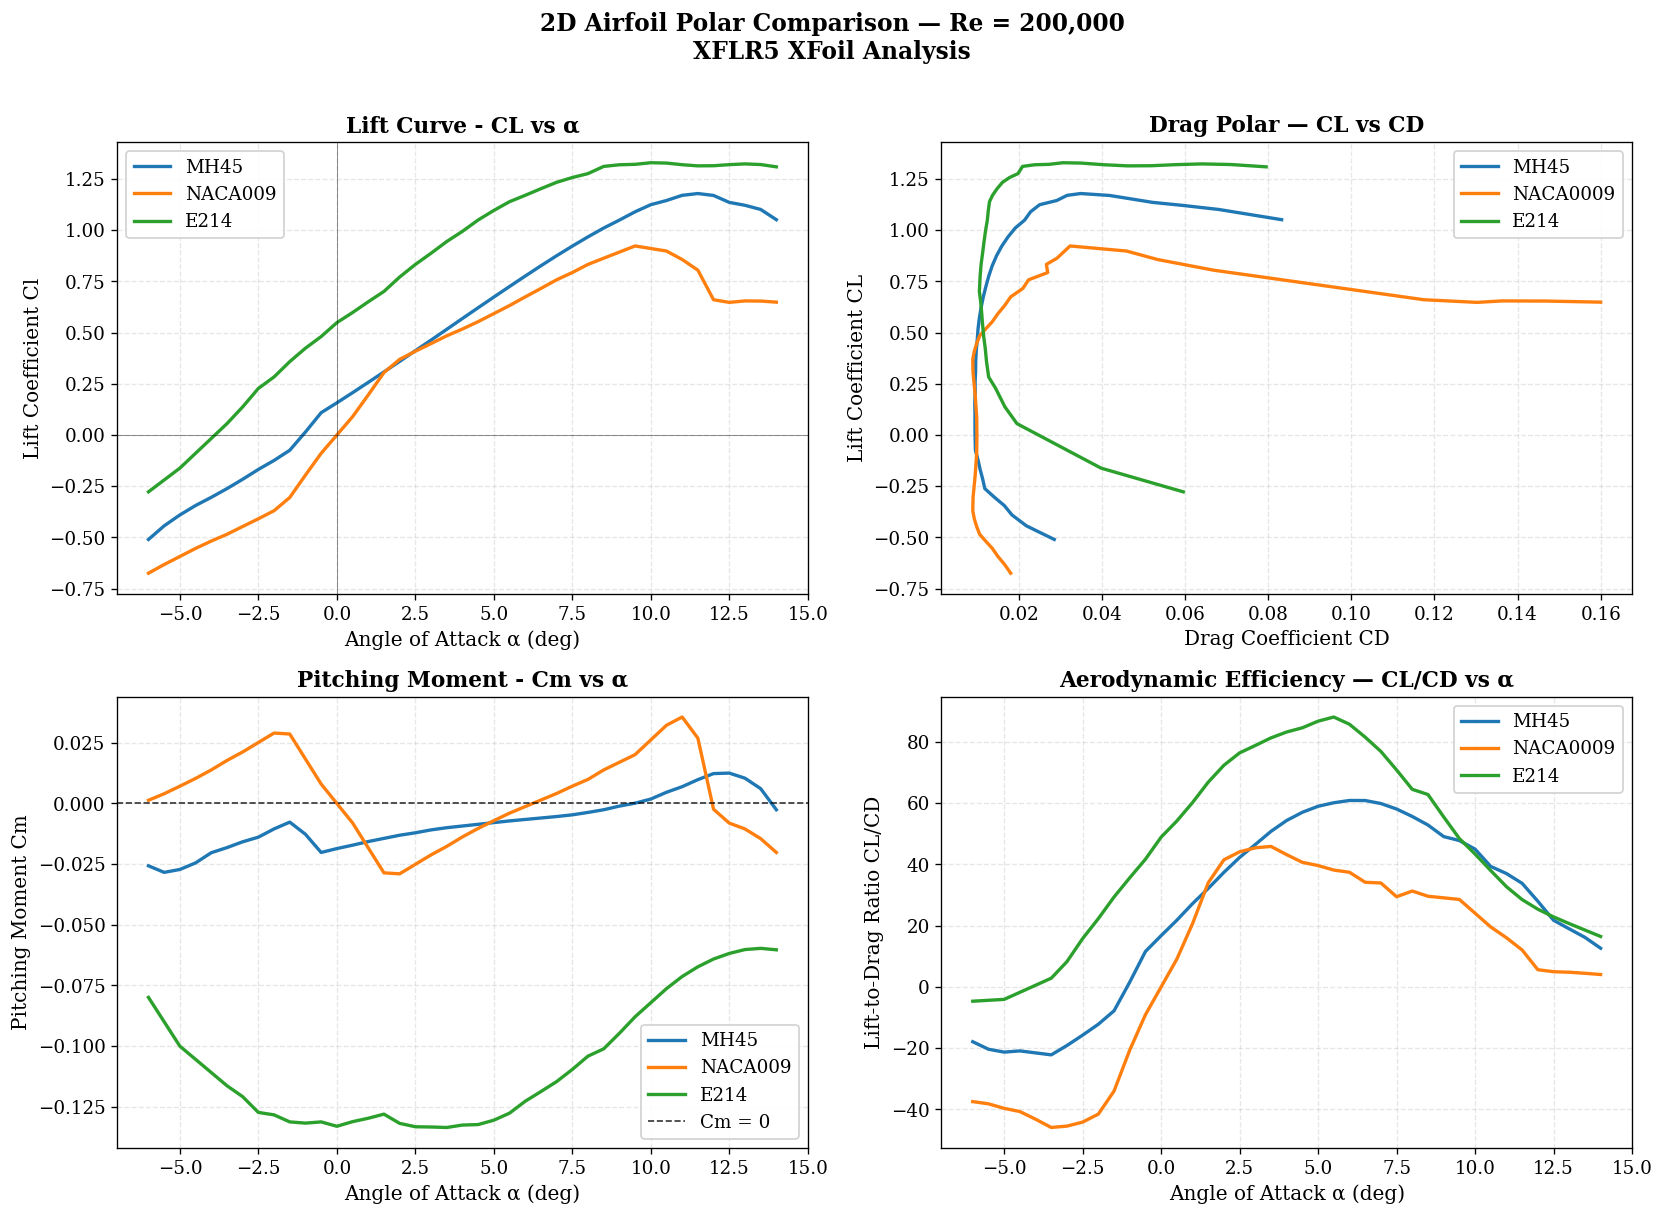

In [3]:
# Define plot size
fig, axes = plt.subplots(2,2, figsize=(14, 10))
fig.suptitle('2D Airfoil Polar Comparison — Re = 200,000\nXFLR5 XFoil Analysis', 
             fontsize=14, fontweight='bold', y=1.01)

# Initialize subplot 
ax_cl_a  = axes[0, 0]  # CL vs Alpha
ax_polar = axes[0, 1]  # CL vs CD (drag polar)
ax_cm    = axes[1, 0]  # Cm vs Alpha
ax_ld    = axes[1, 1]  # CL/CD vs alpha

# Lot Lift Curve 
ax_cl_a.plot(mh45_200k['alpha'], mh45_200k['CL'], label = 'MH45')
ax_cl_a.plot(NACA0009_200k['alpha'], NACA0009_200k['CL'], label = 'NACA009')
ax_cl_a.plot(E214_200k['alpha'], E214_200k['CL'], label = 'E214')                      
ax_cl_a.set_xlabel('Angle of Attack α (deg)')
ax_cl_a.set_ylabel('Lift Coefficient Cl')
ax_cl_a.set_title('Lift Curve - CL vs α')
ax_cl_a.axhline(0, color='k', linewidth=0.5, alpha=0.5)
ax_cl_a.axvline(0, color='k', linewidth=0.5, alpha=0.5)
ax_cl_a.legend()

# Plot Drag Polar
ax_polar.plot(mh45_200k['CD'], mh45_200k['CL'], label = 'MH45')
ax_polar.plot(NACA0009_200k['CD'],NACA0009_200k['CL'], label = 'NACA0009')
ax_polar.plot(E214_200k['CD'],E214_200k['CL'], label = 'E214')
ax_polar.set_xlabel('Drag Coefficient CD')
ax_polar.set_ylabel('Lift Coefficient CL')
ax_polar.set_title('Drag Polar — CL vs CD')
ax_polar.legend()

# Plot Lift/Drag Ratio 
ax_ld.plot(mh45_200k['alpha'], mh45_200k['CL/CD'], label = 'MH45')
ax_ld.plot(NACA0009_200k['alpha'],NACA0009_200k['CL/CD'], label = 'NACA0009')
ax_ld.plot(E214_200k['alpha'],E214_200k['CL/CD'], label = 'E214')
ax_ld.set_xlabel('Angle of Attack α (deg)')
ax_ld.set_ylabel('Lift-to-Drag Ratio CL/CD')
ax_ld.set_title('Aerodynamic Efficiency — CL/CD vs α')
ax_ld.legend()

# Plot Pitching Moment 
ax_cm.plot(mh45_200k['alpha'], mh45_200k['Cm'], label = 'MH45')
ax_cm.plot(NACA0009_200k['alpha'], NACA0009_200k['Cm'], label = 'NACA009')
ax_cm.plot(E214_200k['alpha'], E214_200k['Cm'], label = 'E214')
ax_cm.axhline(0, color='k', linewidth=1.0, alpha=0.8, linestyle='--', label='Cm = 0')                      
ax_cm.set_xlabel('Angle of Attack α (deg)')
ax_cm.set_ylabel('Pitching Moment Cm')
ax_cm.set_title('Pitching Moment - Cm vs α')
ax_cm.legend()
              

# Display figure
plt.tight_layout()
plt.show()

### 3. Reynolds Number Comparison - MH45

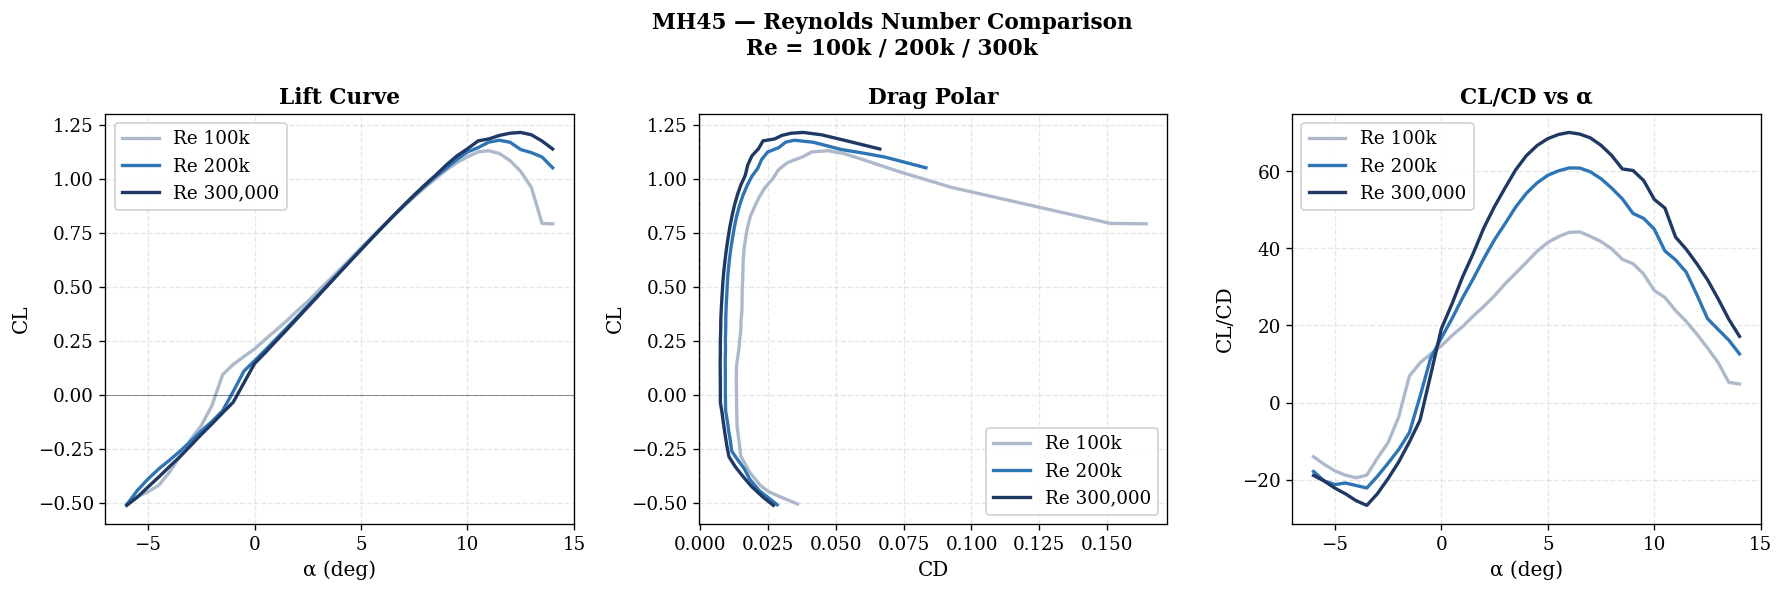

In [10]:
# Load data 
mh45_100k = pd.read_csv(r'C:\Users\colin\OneDrive\Desktop\Xflr5 Processed Data\MH45_Re100k.csv')
mh45_300k = pd.read_csv(r'C:\Users\colin\OneDrive\Desktop\Xflr5 Processed Data\MH45_Re300k.csv')


# Insert Lift/Drag ratio into datasets 
mh45_100k['CL/CD'] = mh45_100k['CL']/mh45_100k['CD']
mh45_300k['CL/CD'] = mh45_300k['CL']/mh45_300k['CD']

# Initialize subplot 
fig, (ax_cl, ax_polar, ax_ratio) = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('MH45 — Reynolds Number Comparison\nRe = 100k / 200k / 300k', 
             fontsize=13, fontweight='bold')

# Generate Lift curve comparisons at Re = 100k,200k,300k
ax_cl.plot(mh45_100k['alpha'],mh45_100k['CL'], color = '#ADB9CA', label = 'Re 100k')
ax_cl.plot(mh45_200k['alpha'],mh45_200k['CL'], color = '#2E75B6', label = 'Re 200k')
ax_cl.plot(mh45_300k['alpha'],mh45_300k['CL'], color = '#1F3864',label = 'Re 300,000')
ax_cl.axhline(0, color='k', linewidth=0.5, alpha=0.5)
ax_cl.set_title('Lift Curve')
ax_cl.set_xlabel('α (deg)')
ax_cl.set_ylabel('CL')
ax_cl.legend()
                                       
# Generate drag polar comparisons at Re = 100k,200k,300k
ax_polar.plot(mh45_100k['CD'],mh45_100k['CL'], color = '#ADB9CA', label = 'Re 100k')
ax_polar.plot(mh45_200k['CD'],mh45_200k['CL'], color = '#2E75B6', label = 'Re 200k')
ax_polar.plot(mh45_300k['CD'],mh45_300k['CL'], color = '#1F3864', label = 'Re 300,000')
ax_polar.set_title('Drag Polar')
ax_polar.set_xlabel('CD')
ax_polar.set_ylabel('CL')
ax_polar.legend()

# Generate CL/CD vs α comparisons at Re = 100k,200k,300k
ax_ratio.plot(mh45_100k['alpha'],mh45_100k['CL/CD'], color = '#ADB9CA', label = 'Re 100k')
ax_ratio.plot(mh45_200k['alpha'],mh45_200k['CL/CD'], color = '#2E75B6', label = 'Re 200k')
ax_ratio.plot(mh45_300k['alpha'],mh45_300k['CL/CD'], color = '#1F3864', label = 'Re 300,000')
ax_ratio.set_title('CL/CD vs α')
ax_ratio.set_xlabel('α (deg)')
ax_ratio.set_ylabel('CL/CD')
ax_ratio.legend()

# Display subplot 
plt.tight_layout()
plt.show()

### 4. Airfoil Comparison Summary Data - Re 200k

In [3]:
# ── Max CL ─────────────────────────────────────────────────────────────────
idx_mh45 = mh45_200k['CL'].idxmax()
idx_naca = NACA0009_200k['CL'].idxmax()
idx_e214 = E214_200k['CL'].idxmax()

CL_max_mh45 = mh45_200k.loc[idx_mh45, 'CL']
CL_max_naca = NACA0009_200k.loc[idx_naca, 'CL']
CL_max_e214 = E214_200k.loc[idx_e214, 'CL']

alpha_at_max_CL_mh45    = mh45_200k.loc[idx_mh45, 'alpha']
alpha_at_max_CL_naca009 = NACA0009_200k.loc[idx_naca, 'alpha']
alpha_at_max_CL_e214    = E214_200k.loc[idx_e214, 'alpha']

# ── Parameters ─────────────────────────────────────────────────────────────
rho      = 1.225
W_N      = 5.89
S_ref    = 0.162
v_cruise = 22

# ── Stall speed ────────────────────────────────────────────────────────────
stall_speed_mh45 = np.sqrt(2 * W_N / (rho * S_ref * CL_max_mh45)) * 3.6
stall_speed_naca = np.sqrt(2 * W_N / (rho * S_ref * CL_max_naca)) * 3.6
stall_speed_e214 = np.sqrt(2 * W_N / (rho * S_ref * CL_max_e214)) * 3.6

# ── Peak CL/CD ─────────────────────────────────────────────────────────────
idx_CL_CD_mh45 = mh45_200k['CL/CD'].idxmax()
idx_CL_CD_naca = NACA0009_200k['CL/CD'].idxmax()
idx_CL_CD_e214 = E214_200k['CL/CD'].idxmax()

max_lift_drag_mh45   = mh45_200k.loc[idx_CL_CD_mh45, 'CL/CD']
max_lift_drag_naca   = NACA0009_200k.loc[idx_CL_CD_naca, 'CL/CD']
max_lift_drag_e214   = E214_200k.loc[idx_CL_CD_e214, 'CL/CD']

alpha_lift_drag_mh45 = mh45_200k.loc[idx_CL_CD_mh45, 'alpha']
alpha_lift_drag_naca = NACA0009_200k.loc[idx_CL_CD_naca, 'alpha']
alpha_lift_drag_e214 = E214_200k.loc[idx_CL_CD_e214, 'alpha']

# ── Minimum CD ─────────────────────────────────────────────────────────────
min_CD_mh45 = mh45_200k['CD'].min()
min_CD_naca = NACA0009_200k['CD'].min()
min_CD_e214 = E214_200k['CD'].min()

# ── Cruise ─────────────────────────────────────────────────────────────────
CL_cruise = W_N / (0.5 * rho * v_cruise**2 * S_ref)

f_mh45 = interp1d(mh45_200k['CL'],     mh45_200k['CD'],     kind='cubic')
f_naca = interp1d(NACA0009_200k['CL'], NACA0009_200k['CD'], kind='cubic')
f_e214 = interp1d(E214_200k['CL'],     E214_200k['CD'],     kind='cubic')

CD_cruise_mh45 = float(f_mh45(CL_cruise))
CD_cruise_naca = float(f_naca(CL_cruise))
CD_cruise_e214 = float(f_e214(CL_cruise))

alpha_cruise_mh45 = np.interp(CL_cruise, mh45_200k['CL'],     mh45_200k['alpha'])
alpha_cruise_naca = np.interp(CL_cruise, NACA0009_200k['CL'], NACA0009_200k['alpha'])
alpha_cruise_e214 = np.interp(CL_cruise, E214_200k['CL'],     E214_200k['alpha'])

cm_cruise_mh45 = np.interp(alpha_cruise_mh45, mh45_200k['alpha'],     mh45_200k['Cm'])
cm_cruise_naca = np.interp(alpha_cruise_naca, NACA0009_200k['alpha'], NACA0009_200k['Cm'])
cm_cruise_e214 = np.interp(alpha_cruise_e214, E214_200k['alpha'],     E214_200k['Cm'])

# ── Metrics ────────────────────────────────────────────────────────────────
metrics = [
    ('CLmax',        'CLmax',                        '{:.3f}',  CL_max_naca,        CL_max_mh45,        CL_max_e214),
    ('alpha_stall',  'Stall AoA (°)',                 '{:.1f}',  alpha_at_max_CL_naca009, alpha_at_max_CL_mh45, alpha_at_max_CL_e214),
    ('V_stall',      'Stall speed (km/h)',            '{:.1f}',  stall_speed_naca,   stall_speed_mh45,   stall_speed_e214),
    ('CL_CD_max',    'Peak CL/CD',                   '{:.2f}',  max_lift_drag_naca, max_lift_drag_mh45, max_lift_drag_e214),
    ('alpha_LD',     'AoA at peak L/D (°)',           '{:.1f}',  alpha_lift_drag_naca, alpha_lift_drag_mh45, alpha_lift_drag_e214),
    ('CD_min',       'CD minimum',                   '{:.4f}',  min_CD_naca,        min_CD_mh45,        min_CD_e214),
    ('CL_cruise',    'CL at cruise',                 '{:.4f}',  CL_cruise,          CL_cruise,          CL_cruise),
    ('alpha_cruise', 'AoA at cruise (°)',             '{:.2f}',  alpha_cruise_naca,  alpha_cruise_mh45,  alpha_cruise_e214),
    ('CD_cruise',    'CD at cruise',                 '{:.4f}',  CD_cruise_naca,     CD_cruise_mh45,     CD_cruise_e214),
    ('Cm_cruise',    'Cm at cruise AoA',             '{:.4f}',  cm_cruise_naca,     cm_cruise_mh45,     cm_cruise_e214),
]

# ── Print table ────────────────────────────────────────────────────────────
col_width   = 22
label_width = 30
total_width = label_width + col_width * 3
title       = "Airfoil Aerodynamic Summary (Re = 200,000)"

headers1 = ["NACA0009", "MH45",  "E214" ]
headers2 = ["Re=200k",  "Re=200k", "Re=200k"]

print()
print(title)
print("=" * total_width)
print(" " * label_width + "".join(f"{h:>{col_width}}" for h in headers1))
print(" " * label_width + "".join(f"{h:>{col_width}}" for h in headers2))
print("-" * total_width)

for _, label, fmt, val_naca, val_mh45, val_e214 in metrics:
    a = fmt.format(val_naca)
    b = fmt.format(val_mh45)
    c = fmt.format(val_e214)
    print(f"{label:<{label_width}}{a:>{col_width}}{b:>{col_width}}{c:>{col_width}}")

print("=" * total_width)


Airfoil Aerodynamic Summary (Re = 200,000)
                                            NACA0009                  MH45                  E214
                                             Re=200k               Re=200k               Re=200k
------------------------------------------------------------------------------------------------
CLmax                                          0.923                 1.179                 1.329
Stall AoA (°)                                    9.5                  11.5                  10.0
Stall speed (km/h)                              28.9                  25.5                  24.1
Peak CL/CD                                     45.86                 60.86                 88.10
AoA at peak L/D (°)                              3.5                   6.0                   5.5
CD minimum                                    0.0089                0.0094                0.0105
CL at cruise                                  0.1226                0.1226         

## Airfoil Selection Overview

All 3 airfoil candidates were analyzed using XFLR5 xfoil direct analysis across AoA = -6° to +14°.

---

**NACA0009 -- Wing A**
Peak CL/CD = 45.8617 
AoA at (CL = 0.123) = 0.6568
Cm at (CL = 0.123) = 0.0057

Chosen as Wing A baseline due to symmetric airfoil having predictable flight characteristics perfect for comparing performance against MH45 airfoil. 

**Mh45 -- Wing B & Wing C**  
Peak CL/CD = 60.8627 (33% improvement)
AoA at (Cl = 0.123) = - 0.3592
Cm at (Cl = 0.123)  = = -.00197 

Chosen for Wing B and Wing C to compare effect of airfoil and planform against baseline. Clear improvement in drag polar and near 0 angle of attack and moment coefficient should lead to stable flight at cruise. 

**E219 -- Eliminated**  
Negative Cm throughout AoA range and large Cm at cruise (-3.0903) means elevons will have to constantly adjust upwards leaving less surface area for stability and greater trim drag. 

---
